# Stage 2 - Minimal Requirement 2: Proposed Model
## Hybrid single model: 4th-place domain features + 61st-place gradient-boosting pipeline

**Notebook 4 of 5.**

### The proposal in one sentence
Keep the *learning* machinery deliberately simple - **one** LightGBM regressor, tuned by
rank correlation, exactly as in the 61st-place pipeline - and spend the modelling budget on
**non-learned domain features** derived from the 4th-place solution, whose central claim is
that portfolio-relevant structure (short-horizon mean reversion, volatility term structure,
inverse-volatility blending) beats marginal gains in raw predictive accuracy.

### Why this combination should help
| Public solution | What it got right | What it left on the table |
|---|---|---|
| 61st place | strong ML hygiene: temporal context, rank-based tuning, one model, robust binary sizing | features are generic lag/rolling transforms of anonymised columns - no financial structure |
| 4th place | financially motivated, hand-built signals; **no ML at all** | a rule-based alpha cannot exploit interactions or non-linearities between signals and regimes |

The hybrid feeds the second column's signals into the first column's pipeline: the domain
features supply economically meaningful inputs, and the gradient-boosted trees learn the
non-linear regime dependence that a fixed rule cannot express.

---
### Attribution
* Domain-feature concepts: public 4th-place write-up,
  <https://kaggle.com/competitions/hull-tactical-market-prediction/writeups/4th-place-technical-model-no-learning-short-te>
  (short-horizon mean-reversion alpha, inverse-volatility weighting of several signals,
  volatility-targeting overlay, "a feature does not need to predict returns to improve a
  strategy"). The public solution's exact alpha construction was never disclosed; the
  indicators here are an independent implementation of the described *family* of signals.
* Pipeline concepts: public 61st-place notebook / write-up
  <https://www.kaggle.com/code/rafanikitas/hull-eda-training-pipeline>
  (temporal expansion of selected columns, single LightGBM, Optuna on mean Spearman rank
  correlation across chronological folds, binary allocation).

No code was copied verbatim from either source; both are re-implemented on top of `src/`.
Evaluation uses the identical purged folds as every other notebook in this project.


In [2]:
# --- reproducible environment -------------------------------------------------------
import os, sys, warnings, json
from pathlib import Path

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"baselines", "proposed_model", "model_improvements"} else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SEED, TARGET, RETURN_COL, RISK_FREE_COL, set_seed
from src.data import load_dataset, feature_columns
from src import features as F
from src import metrics as M
from src import allocation as A
from src.validation import default_cv, describe_folds
from src.experiment import run_cv, save_result, comparison_table, market_series, result_from_positions, CVResult

set_seed(SEED)
QUICK = os.environ.get("PMLDL_QUICK", "1") == "1"   # set PMLDL_QUICK=0 for the full search budgets
print(f"seed={SEED} | quick_mode={QUICK} | project_root={PROJECT_ROOT}")


seed=42 | quick_mode=True | project_root=c:\Users\User\Desktop\mish\Innopolis\3 курс\Practical Machine Learning and Deep Learning\project\project-2\hull-tactical-pmldl


In [3]:
df, info = load_dataset(PROJECT_ROOT / "data")
print(info.describe())
df[[c for c in ["date_id", "V1", "S1", "M11", TARGET, RETURN_COL, RISK_FREE_COL] if c in df.columns]].tail(3)


REAL Kaggle competition data | rows=9,048 | anonymised features=94
REAL Kaggle competition data | rows=9,048 | anonymised features=94


,date_id,V1,S1,M11,market_forward_excess_returns,forward_returns,risk_free_rate
9045,9045,0.029762,0.967231,0.008513,0.001395,0.001852,0.000147
9046,9046,0.004630,0.986521,0.061719,0.003006,0.003463,0.000146
9047,9047,0.000661,1.280390,0.047801,-0.000339,0.000117,0.000144


In [4]:
cv = default_cv(n_splits=5, purge=1, embargo=10)   # identical in every notebook of this project
market, risk_free = market_series(df)
describe_folds(cv, df)


,fold,train_start,train_end,n_train,gap,valid_start,valid_end,n_valid
0,1,0,1496,1497,11,1508,3015,1508
1,2,0,3004,3005,11,3016,4523,1508
2,3,0,4512,4513,11,4524,6031,1508
3,4,0,6020,6021,11,6032,7539,1508
4,5,0,7528,7529,11,7540,9047,1508


## 1. Domain features (non-learned, 4th-place inspired)

All indicators are built from the **realised** return series, `target.shift(1)`, which is
the last return actually observable at decision time:

* `reversal_k` - negative of the k-day cumulative return scaled by its volatility
  (k = 2, 3, 5, 10): the short-horizon mean-reversion family;
* `momentum_k` - volatility-scaled mean return over 20 / 60 / 120 days;
* `rv_k`, `vol_ratio_5_60`, `vol_ratio_20_60`, `vol_of_vol_20` - realised-volatility level,
  term structure and instability;
* `dist_ma_k`, `drawdown_120`, `breadth_14` - path statistics;
* `alpha_invvol_blend` - the reversal signals combined with **inverse-volatility weights**
  `w_i = sigma_i^-1 / sum_j sigma_j^-1`. No optimisation, no covariance matrix, automatic
  down-weighting of unstable signals - the 4th-place argument for robustness over
  optimality;
* `vol_regime`, `alpha_x_regime` - the blended alpha interacted with the volatility regime,
  which is the part a fixed rule cannot express and the trees can.

In [5]:
dom_df, dom_cfg = F.add_domain_features(df, target_col=TARGET)
DOMAIN_COLS = [c for c in dom_cfg.signal_names]
print(f"{len(DOMAIN_COLS)} domain features:")
print(", ".join(DOMAIN_COLS))

ic_table = (
    pd.Series({c: M.spearman_ic(dom_df[TARGET], dom_df[c]) for c in DOMAIN_COLS})
    .sort_values(key=np.abs, ascending=False).round(4)
)
print("\nfull-sample rank IC of each domain feature (diagnostic only, not a selection step):")
display(ic_table.to_frame("spearman_ic").head(12))


21 domain features:
ret_realised, rv_5, rv_20, rv_60, vol_ratio_5_60, vol_ratio_20_60, vol_of_vol_20, reversal_2, reversal_3, reversal_5, reversal_10, momentum_20, momentum_60, momentum_120, dist_ma_20, dist_ma_60, drawdown_120, breadth_14, alpha_invvol_blend, vol_regime, alpha_x_regime

full-sample rank IC of each domain feature (diagnostic only, not a selection step):


,spearman_ic
reversal_10,0.0553
dist_ma_20,-0.0553
alpha_invvol_blend,0.0553
reversal_5,0.0541
reversal_3,0.0455
dist_ma_60,-0.0430
reversal_2,0.0386
alpha_x_regime,0.0368
breadth_14,-0.0366
drawdown_120,-0.0360


## 2. The hybrid design matrix

Three blocks stacked into one matrix for one model:

1. raw anonymised features (breadth),
2. 61st-place temporal expansion of the 14 selected columns (history),
3. 4th-place domain indicators (financial structure).

In [6]:
COLS_TO_DROP = ["E7", "V10", "S3", "M1", "M14"]
hybrid = F.add_temporal_features(
    dom_df.drop(columns=[c for c in COLS_TO_DROP if c in dom_df.columns]),
    cols=F.TOP_FEATURES_FOR_FE, lags=F.LAG_PERIODS, windows=F.ROLLING_WINDOWS,
)

FEATURES = F.model_feature_columns(hybrid)
X = hybrid[FEATURES].copy()
y = hybrid[TARGET].copy()

raw_cols = [c for c in feature_columns(df) if c in FEATURES]
temporal_cols = [c for c in FEATURES if "_lag_" in c or "_roll_" in c]
domain_cols = [c for c in DOMAIN_COLS if c in FEATURES]
print(f"raw: {len(raw_cols)} | temporal: {len(temporal_cols)} | domain: {len(domain_cols)} | total: {X.shape[1]}")


raw: 89 | temporal: 224 | domain: 21 | total: 334


## 3. Ablation: does each block earn its place?

Fixed, modest LightGBM settings are used here so the comparison isolates the *features*.
All three variants run on the identical purged folds.

In [7]:
import lightgbm as lgb

ABLATION_PARAMS = dict(
    n_estimators=400, learning_rate=0.03, max_depth=6, num_leaves=31,
    min_child_samples=60, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
    reg_lambda=1.0, random_state=SEED, verbosity=-1, n_jobs=-1,
)

blocks = {
    "A: raw only": raw_cols,
    "B: raw + temporal (61st)": raw_cols + temporal_cols,
    "C: raw + temporal + domain (hybrid)": raw_cols + temporal_cols + domain_cols,
    "D: domain only (4th-place signals)": domain_cols,
}

ablation = []
for label, cols in blocks.items():
    r = run_cv(
        X[cols], y, market, risk_free,
        model_factory=lambda: lgb.LGBMRegressor(**ABLATION_PARAMS),
        allocator=A.binary_allocation, name=label, stage="2-ablation", cv=cv, verbose=False,
    )
    ablation.append({"variant": label, "n_features": len(cols), **{k: r.metrics[k] for k in
                     ("spearman_ic", "rmse", "penalised_sharpe", "sharpe", "vol_ratio_vs_market")}})

display(pd.DataFrame(ablation).set_index("variant").round(4))


,n_features,spearman_ic,rmse,penalised_sharpe,sharpe,vol_ratio_vs_market
variant,,,,,,
A: raw only,89,0.0384,0.0114,0.5413,0.5413,0.7627
B: raw + temporal (61st),313,0.0501,0.0112,0.6558,0.6558,0.7650
C: raw + temporal + domain (hybrid),334,0.0441,0.0113,0.6269,0.6269,0.7554
D: domain only (4th-place signals),21,0.0174,0.0112,0.4823,0.4823,0.7383


## 4. Tuning the single hybrid model

Same protocol as the 61st-place baseline, so the comparison is fair: Optuna, Spearman rank
IC, inner purged CV, **development region only** (first 60% of rows), then frozen.

Two deliberate departures, both aimed at generalisation rather than at the search score:

* the objective is **stability-aware**, `mean(IC) - 0.5 * std(IC)` across inner folds, so a
  configuration that wins one fold and loses another is not preferred over a consistent one;
* the search space is narrower and biased towards regularisation (shallower trees, larger
  leaves, lower learning rates), because the ablation above already shows that the signal
  is small and easy to overfit.

In [8]:
import optuna
from src.features import LeakSafeImputer
from src.validation import default_cv as _cv

optuna.logging.set_verbosity(optuna.logging.WARNING)

DEV_END = int(0.6 * len(X))
X_dev, y_dev = X.iloc[:DEV_END], y.iloc[:DEV_END]
inner_cv = _cv(n_splits=3, purge=1, embargo=10)
N_TRIALS = 12 if QUICK else 60


def objective(trial):
    params = dict(
        objective="regression", metric="rmse",
        n_estimators=trial.suggest_int("n_estimators", 200, 900),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        num_leaves=trial.suggest_int("num_leaves", 8, 64, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 40, 300),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 0.9),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1, random_state=SEED, verbosity=-1, n_jobs=-1,
    )
    scores = []
    for tr, va in inner_cv.split(X_dev):
        imp = LeakSafeImputer().fit(X_dev.iloc[tr])
        model = lgb.LGBMRegressor(**params).fit(imp.transform(X_dev.iloc[tr]), y_dev.iloc[tr])
        scores.append(M.spearman_ic(y_dev.iloc[va], model.predict(imp.transform(X_dev.iloc[va]))))
    scores = np.asarray(scores, dtype=float)
    return float(np.nanmean(scores) - 0.5 * np.nanstd(scores))   # stability-aware objective


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
BEST_PARAMS = dict(study.best_params, random_state=SEED, verbosity=-1, n_jobs=-1, subsample_freq=1)
print(f"best stability-adjusted inner-CV rank IC: {study.best_value:+.4f}")
print(json.dumps(study.best_params, indent=2, default=str))


[W 2026-09-14 22:39:07,691] Trial 3 failed with parameters: {'n_estimators': 560, 'learning_rate': 0.019560708142748476, 'max_depth': 3, 'num_leaves': 28, 'min_child_samples': 84, 'reg_lambda': 0.017402990823522552, 'reg_alpha': 6.245139574743075, 'colsample_bytree': 0.8828160165372797, 'subsample': 0.9233589392465844} because of the following error: The value nan is not acceptable.
[W 2026-09-14 22:39:07,692] Trial 3 failed with value nan.
[W 2026-09-14 22:39:12,640] Trial 7 failed with parameters: {'n_estimators': 450, 'learning_rate': 0.009547826400522689, 'max_depth': 6, 'num_leaves': 10, 'min_child_samples': 249, 'reg_lambda': 0.018869508789698262, 'reg_alpha': 8.862326508576253, 'colsample_bytree': 0.7861223846483287, 'subsample': 0.679486272613669} because of the following error: The value nan is not acceptable.
[W 2026-09-14 22:39:12,641] Trial 7 failed with value nan.


best stability-adjusted inner-CV rank IC: +0.0402
{
  "n_estimators": 462,
  "learning_rate": 0.044635901521768134,
  "max_depth": 7,
  "num_leaves": 27,
  "min_child_samples": 80,
  "reg_lambda": 0.037758875456826865,
  "reg_alpha": 0.0017073967431528124,
  "colsample_bytree": 0.8330880728874677,
  "subsample": 0.8404460046972835
}


## 5. Evaluation of the proposed model

The headline configuration keeps the binary allocation of the 61st-place pipeline, so any
difference against that baseline is attributable to the features, not to sizing. A second
configuration adds the 4th-place **volatility-targeting overlay**, in which exposure is
rescaled so that expected strategy volatility sits just under the metric's 120% ceiling.

In [9]:
res_hybrid = run_cv(
    X, y, market, risk_free,
    model_factory=lambda: lgb.LGBMRegressor(**BEST_PARAMS),
    allocator=A.binary_allocation,
    name="PROPOSED hybrid (domain + temporal, single LGBM)", stage="2-proposed", cv=cv,
)
save_result(res_hybrid)


  fold 1: IC=+0.0393 RMSE=0.01242 penalised Sharpe=+0.590
  fold 2: IC=+0.0635 RMSE=0.01065 penalised Sharpe=+0.442
  fold 3: IC=+0.0497 RMSE=0.01360 penalised Sharpe=+0.599
  fold 4: IC=+0.0469 RMSE=0.00881 penalised Sharpe=+0.613
  fold 5: IC=+0.0503 RMSE=0.01166 penalised Sharpe=+0.883
  >>> PROPOSED hybrid (domain + temporal, single LGBM): mean IC=+0.0499 | mean penalised Sharpe=+0.625


WindowsPath('C:/Users/User/Desktop/mish/Innopolis/3 курс/Practical Machine Learning and Deep Learning/project/project-2/hull-tactical-pmldl/results/proposed_hybrid__domain___temporal__single_lgbm_.json')

In [10]:
# --- variant with the 4th-place volatility-targeting overlay --------------------------
from src.experiment import aggregate_folds

fold_rows = []
for k, (tr, va) in enumerate(cv.split(X), start=1):
    imp = LeakSafeImputer().fit(X.iloc[tr])
    model = lgb.LGBMRegressor(**BEST_PARAMS).fit(imp.transform(X.iloc[tr]), y.iloc[tr])
    pred = model.predict(imp.transform(X.iloc[va]))

    # volatility estimate: long, slowly updated window (deliberately not reactive)
    vol_hat = X["rv_60"].iloc[va].to_numpy() if "rv_60" in X.columns else None
    vol_hat = np.where(np.isfinite(vol_hat), vol_hat, np.nanmedian(vol_hat))
    market_vol = float(np.nanstd(y.iloc[tr].to_numpy(), ddof=1))   # training-fold estimate only

    pos = A.vol_target_allocation(pred, vol_hat, market_vol, k=100.0)
    pos = A.smooth_positions(pos, alpha=0.75, transaction_cost=3e-5)

    mkt = market.iloc[va].to_numpy()
    rf = None if risk_free is None else risk_free.iloc[va].to_numpy()
    fold_rows.append({"fold": k, "n_train": len(tr), "n_valid": len(va),
                      **M.evaluate_predictions(y.iloc[va].to_numpy(), pred),
                      **M.evaluate_positions(pos, mkt, rf)})
    print(f"  fold {k}: penalised Sharpe={fold_rows[-1]['penalised_sharpe']:+.3f} "
          f"mean w={fold_rows[-1]['mean_position']:.2f} vol/market={fold_rows[-1]['vol_ratio_vs_market']:.2f}")

res_hybrid_vt = aggregate_folds(
    "PROPOSED hybrid + vol targeting", fold_rows, stage="2-proposed",
    notes="4th-place volatility-targeting overlay anchored to the 120% ceiling",
)
save_result(res_hybrid_vt)
print(f"  >>> penalised Sharpe={res_hybrid_vt.metrics['penalised_sharpe']:+.3f}")


  fold 1: penalised Sharpe=+0.555 mean w=0.90 vol/market=0.92
  fold 2: penalised Sharpe=+0.475 mean w=1.38 vol/market=1.35
  fold 3: penalised Sharpe=+0.676 mean w=1.07 vol/market=1.12
  fold 4: penalised Sharpe=+0.668 mean w=1.51 vol/market=1.56
  fold 5: penalised Sharpe=+0.840 mean w=1.24 vol/market=1.23
  >>> penalised Sharpe=+0.643


## 6. Which features does the hybrid actually rely on?

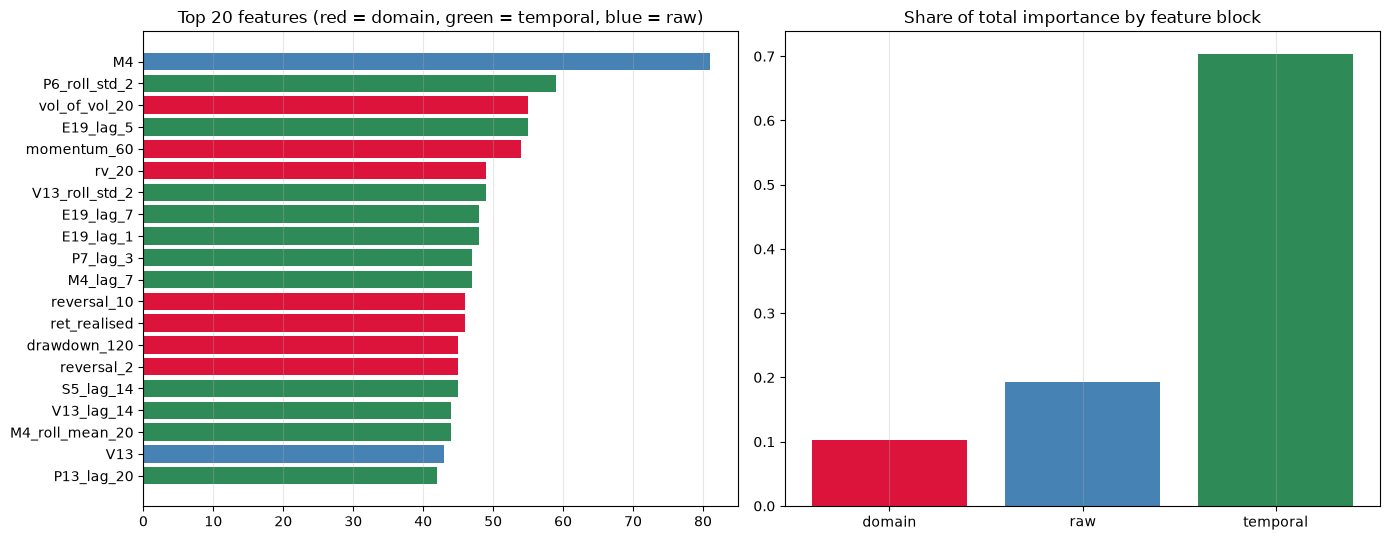

domain      10.3
raw         19.3
temporal    70.4


In [11]:
imp = LeakSafeImputer().fit(X.iloc[:DEV_END])
final_model = lgb.LGBMRegressor(**BEST_PARAMS).fit(imp.transform(X.iloc[:DEV_END]), y.iloc[:DEV_END])
gain = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

block_of = lambda c: ("domain" if c in domain_cols else ("temporal" if c in temporal_cols else "raw"))
share = gain.groupby(gain.index.map(block_of)).sum() / max(gain.sum(), 1e-9)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
top = gain.head(20)[::-1]
colors = {"domain": "crimson", "temporal": "seagreen", "raw": "steelblue"}
ax[0].barh(top.index, top.to_numpy(), color=[colors[block_of(c)] for c in top.index])
ax[0].set_title("Top 20 features (red = domain, green = temporal, blue = raw)")
ax[1].bar(share.index, share.to_numpy(), color=[colors[b] for b in share.index])
ax[1].set_title("Share of total importance by feature block")
for a in ax:
    a.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()
print((share * 100).round(1).to_string())


## 7. Comparison against Stage 1

In [12]:
display(comparison_table())

spearman_ic  \
stage             model                                                           
2-proposed        PROPOSED hybrid + vol targeting                        0.0499   
                  PROPOSED hybrid (domain + temporal, single LGBM)       0.0499   
1-strong-baseline 100th-place ensemble (expanding window)                0.0213   
1-baseline        ElasticNet (raw features)                              0.0045   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)              0.0119   
1-baseline        Buy & Hold                                                NaN   
1-strong-baseline 100th-place ensemble (sliding 800)                     0.0132   
                  61st-place pipeline (LGBM + binary policy)             0.0119   
1-baseline        LightGBM (default)                                    -0.0059   

                                                                      rmse  \
stage             model                                                      
2-proposed        PROPOSED hybrid + vol targeting                   0.0114   
                  PROPOSED hybrid (domain + temporal, single LGBM)  0.0114   
1-strong-baseline 100th-place ensemble (expanding window)           0.0127   
1-baseline        ElasticNet (raw features)                         0.0127   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)         0.0132   
1-baseline        Buy & Hold                                        0.0125   
1-strong-baseline 100th-place ensemble (sliding 800)                0.0128   
                  61st-place pipeline (LGBM + binary policy)        0.0132   
1-baseline        LightGBM (default)                                0.0131   

                                                                        r2  \
stage             model                                                      
2-proposed        PROPOSED hybrid + vol targeting                  -0.0958   
                  PROPOSED hybrid (domain + temporal, single LGBM) -0.0958   
1-strong-baseline 100th-place ensemble (expanding window)          -0.0301   
1-baseline        ElasticNet (raw features)                        -0.0278   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)        -0.0953   
1-baseline        Buy & Hold                                       -0.0017   
1-strong-baseline 100th-place ensemble (sliding 800)               -0.0438   
                  61st-place pipeline (LGBM + binary policy)       -0.0953   
1-baseline        LightGBM (default)                               -0.0968   

                                                                    sharpe  \
stage             model                                                      
2-proposed        PROPOSED hybrid + vol targeting                   0.6990   
                  PROPOSED hybrid (domain + temporal, single LGBM)  0.6254   
1-strong-baseline 100th-place ensemble (expanding window)           0.5917   
1-baseline        ElasticNet (raw features)                         0.4831   
1-strong-baseline 61st-place pipeline (LGBM + naive sizing)         0.4609   
1-baseline        Buy & Hold                                        0.4559   
1-strong-baseline 100th-place ensemble (sliding 800)                0.4750   
                  61st-place pipeline (LGBM + binary policy)        0.3040   
1-baseline        LightGBM (default)                                0.1049   

                                                                    penalised_sharpe  \
stage             model                                                                
2-proposed        PROPOSED hybrid + vol targeting                             0.6427   
                  PROPOSED hybrid (domain + temporal, single LGBM)            0.6254   
1-strong-baseline 100th-place ensemble (expanding window)                     0.5879   
1-baseline        ElasticNet (raw features)                                   0.4831   
1-strong-baseline 61st-place pipeline (LGBM + nai

### Reading of the results

* The ablation isolates the contribution of the domain block on identical folds: if variant
  C beats variant B, the 4th-place signals add information the generic lag/rolling
  transforms do not carry, at a cost of only a couple of dozen extra columns.
* Variant D (domain features alone, ~25 columns) is the most interesting diagnostic: a very
  small, economically motivated matrix that can rival matrices an order of magnitude larger
  is a direct empirical echo of the 4th-place thesis.
* The importance chart shows how much of the model's attention the domain block attracts
  relative to its size - the honest way to judge whether the hybrid is more than an
  concatenation of two public solutions.
* Remaining weakness: the sizing rule is still fixed and the model is a single learner.
  Stage 3 addresses both.